# **GRUPO 3**

Integrantes:
- Juan Carlos Heredia Vallejo
- Jonathan Fernando Tisalema Lascano


**Nota:** A fin de identificar las modificaciones realizadas, las mismas serán identificadas por ** antes de su título o párrafo correspondiente.

<small>
Feedback recibido:

- Inconsistencia en la Comparación (Violación del principio Ceteris Paribus). En el "Enfoque Incorrecto" entrenaron una Regresión Logística estándar. En el "Enfoque Correcto", entrenaron una Regresión Logística con class_weight='balanced'. Cambiaron dos variables a la vez (la ubicación del preprocesamiento Y el balanceo de clases). No pueden afirmar que la mejora en el ROC-AUC (de 0.51 a 0.74) se debe al uso del Pipeline. De hecho, es casi seguro que la mejora se debe exclusivamente al parámetro class_weight. Para medir el impacto real del Data Leakage, debieron usar class_weight='balanced' en ambos experimentos. De lo contrario, la comparación es injusta y las conclusiones sobre el Pipeline quedan contaminadas.
- Elección del Escalador para Datos Financieros sus boxplots muestran claramente que variables como Income y LoanAmount tienen muchos outliers (clientes muy ricos o préstamos muy grandes, lo cual es normal en banca). En su Pipeline, utilizaron StandardScaler. Este escalador resta la media y divide por la desviación estándar. Al tener outliers fuertes, la media se desplaza y la desviación crece, "aplastando" la distribución de la mayoría de los clientes normales en un rango muy pequeño. En arquitectura de datos financieros, cuando hay outliers legítimos, se debe usar RobustScaler (que usa medianas y rangos intercuartílicos) o aplicar una Transformación Logarítmica (PowerTransformer) para normalizar la distribución antes de escalar. StandardScaler es muy sensible a esos millonarios del dataset.
</small>

# 1.- Selección de la fuente de Datos

## **Conjunto de datos de predicción de impago de préstamos**

Los datos de este dataset se basan en información financiera y personal de los solicitantes de préstamos, que permite analizar su riesgo de impago. Generalmente incluyen variables como:

Datos demográficos: edad, género, estado civil, educación, número de dependientes.

Información financiera: ingresos, deudas actuales, historial crediticio, monto solicitado, duración del préstamo, tasa de interés.

Historial de pagos: registros de pagos anteriores, retrasos, morosidad.

Variables categóricas y numéricas que reflejan el comportamiento del cliente frente a obligaciones financieras.

**Descripción de columnas:**

- **LoanID** : Identificador único para cada préstamo.

- **Age** : Edad del solicitante del préstamo.

- **Income**: Ingreso anual del solicitante.

- **LoanAmount** : Monto del dinero solicitado en el préstamo.

- **CreditScore** : Puntaje crediticio del solicitante, que indica su solvencia.

- **MonthsEmployed** : Número de meses que el solicitante ha estado empleado.

- **NumCreditLines** : Número de líneas de crédito abiertas por el solicitante.

- **InterestRate** : Tasa de interés aplicada al préstamo.

- **LoanTerm** : Duración del préstamo en meses.

- **DTIRatio** : Relación deuda-ingreso, que indica la deuda en comparación con el ingreso del solicitante.

- **Education** : Nivel más alto de educación alcanzado (PhD, Maestría, Licenciatura, Escuela secundaria).

- **EmploymentType** : Tipo de empleo del solicitante (tiempo completo, medio tiempo, autónomo, desempleado).

- **MaritalStatus** : Estado civil del solicitante (soltero, casado, divorciado).

- **HasMortgage** : Indica si el solicitante tiene hipoteca (Sí o No).

- **HasDependents** : Indica si el solicitante tiene personas a su cargo (Sí o No).

- **LoanPurpose** : Propósito del préstamo (hogar, auto, educación, negocios, otros).

- **HasCoSigner** : Indica si el préstamo tiene un co-firmante (Sí o No).

- **Default** : Variable objetivo binaria que indica si el préstamo fue incumplido (1) o no (0).

**Importancia:**

Estos datos permiten que los modelos de aprendizaje automático aprendan patrones asociados a personas con mayor riesgo de incumplimiento, ayudando a predecir quiénes podrían no pagar su préstamo y facilitando decisiones de mitigación de riesgos por parte de las empresas.

# 2.- Adquisición de Datos

## 2.1. Carga de datos

In [ ]:
# Librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Importar dataset de Kaggle con kagglehub
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nikhil1e9/loan-default",           # Nombre del dataset en Kaggle
    "Loan_default.csv",                 # Archivo CSV dentro del dataset
    pandas_kwargs={"sep": ",", "encoding": "latin1"}  # Ajusta encoding si es necesario
)

# Mostrar las primeras filas
df.head()

Using Colab cache for faster access to the 'loan-default' dataset.


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


Dimensiones del dataset: (255347, 18)

Tipos de variables:
 LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

Valores faltantes por columna:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Resumen estadístico (numéricas):
                 Ag

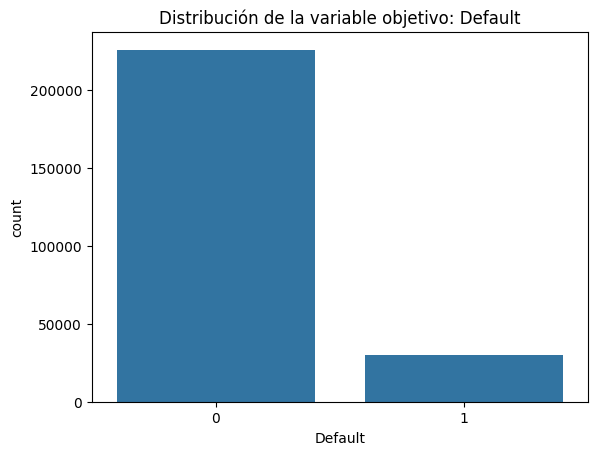

In [ ]:
# Información general
print("Dimensiones del dataset:", df.shape)
print("\nTipos de variables:\n", df.dtypes)

# Valores faltantes
print("\nValores faltantes por columna:")
print(df.isnull().sum())

# Resumen estadístico numérico
print("\nResumen estadístico (numéricas):")
print(df.describe())

# Resumen estadístico categórico
print("\nResumen estadístico (categóricas):")
print(df.describe(include='object'))

sns.countplot(x='Default', data=df)
plt.title('Distribución de la variable objetivo: Default')
plt.show()


Conclusiones Sobre la limpieza de datos

- No hay valores faltantes, lo que simplifica la limpieza de datos antes de modelar.
- Las variables categóricas no tienen valores faltantes
- Las variables categóricas tienen pocos niveles, lo que facilita su codificación para modelos de clasificación
- Los histogramas y boxplots serán útiles para confirmar la presencia de outliers y la distribución de datos antes de entrenar modelos
- La variable objetivo Default está desbalanceada, por lo que habrá que considerar técnicas de balanceo si se entrena un modelo

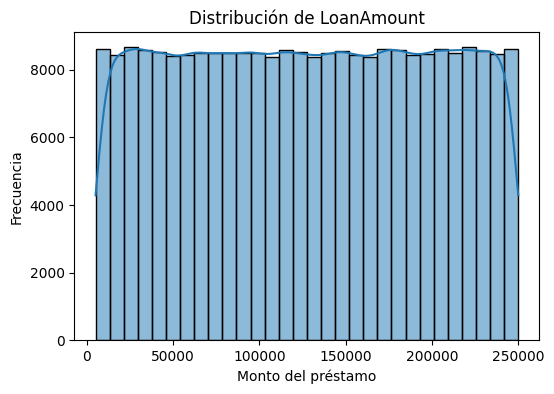


Objetivo: Ver la distribución de los montos de los préstamos y detectar concentraciones o valores extremos.



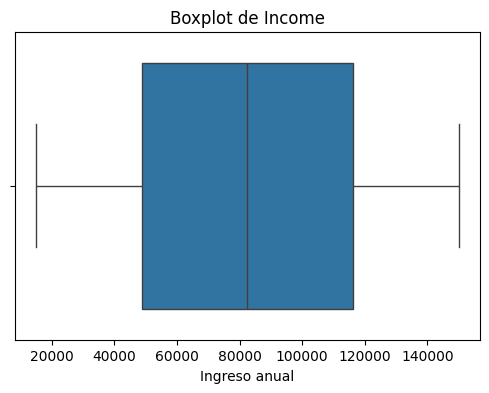


Objetivo: Detectar outliers en los ingresos que podrían influir en los modelos de predicción.



In [ ]:
# 1️⃣ Histograma de LoanAmount
plt.figure(figsize=(6,4))
sns.histplot(df['LoanAmount'], kde=True, bins=30)
plt.title('Distribución de LoanAmount')
plt.xlabel('Monto del préstamo')
plt.ylabel('Frecuencia')
plt.show()
print("\nObjetivo: Ver la distribución de los montos de los préstamos y detectar concentraciones o valores extremos.\n")

# 2️⃣ Boxplot de Income
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Income'])
plt.title('Boxplot de Income')
plt.xlabel('Ingreso anual')
plt.show()
print("\nObjetivo: Detectar outliers en los ingresos que podrían influir en los modelos de predicción.\n")

# 3.- Implementar Efoques

## 3.1.- Enfoque incorrecto (con posible data leakage)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer # Added PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
import numpy as np

# Variables predictoras y objetivo
X = df.drop(columns=['Default', 'LoanID'])
y = df['Default']

# Enfoque incorrecto: escalado antes del split con riesgo de data leakage
num_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
                'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
cat_features = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
                'HasDependents', 'LoanPurpose', 'HasCoSigner']

# Codificación de categóricas
X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)

# ** Escalado numérico
scaler = PowerTransformer(method='yeo-johnson') #Reemplazar StandardScaler por PowerTransformer
X_encoded[num_features] = scaler.fit_transform(X_encoded[num_features])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

# Modelo de regresión logística
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

# ** Modelo de regresión logística
model2 = LogisticRegression(max_iter=5000, class_weight='balanced') # Se agrega el parametro class_weight
model2.fit(X_train, y_train)

# **Predicciones
y_pred2 = model2.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred2))
print("ROC AUC:", roc_auc_score(y_test, y_pred2))

Accuracy: 0.8850858299066641
ROC AUC: 0.5166049710644918
Accuracy: 0.6797075908883232
ROC AUC: 0.6844884972057363


**Interpretación:**
Debido a que la variable objetivo es muy desvalanceada se opta por ocupar ROC AUC que maneja la  curva que muestra la relación entre valores verdaderos y falsos o 0 y 1 entre los datos.

** Adicionalmente, aunque en la data utilizada no se presenta el caso, las variables ingresos anuales o montos de préstamos pueden presentar valores atípicos debido a clientes con alto poder adquisitivo, se opta por aplicar PowerTransformer para transformar y estabilizar la distribución de los datos. Este método reduce la asimetría y el impacto de valores extremos mediante una transformación de potencia (como Yeo-Johnson), logrando una escala más homogénea sin eliminar la información relevante de los valores altos. De esta manera, se mejora la estabilidad del modelo y se evita que los valores atípicos influyan desproporcionadamente en los coeficientes de la regresión logística.

Accuracy: 0.885 Parece alto, pero engañoso.

ROC AUC: 0.516 Casi como adivinar al azar.

El modelo parece predecir bien  la clase mayoritaria (pagos), pero no identifica correctamente los incumplimientos, lo que lo hace inútil para la práctica real.

** Al añadir el parámetro class_weight debido a tratarse de una data desbalanceada, el parámetro ROC se torna más robusto y pasa de 0.52 a 0.68, demostrando un mejor rendimiento del modelo al considerar el parámetro mencionado

## 3.2.- Enfoque adecuado

In [ ]:
# Variables predictoras y objetivo
X = df.drop(columns=['Default', 'LoanID'])
y = df['Default']

# Separar numéricas y categóricas
num_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
                'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
cat_features = ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
                'HasDependents', 'LoanPurpose', 'HasCoSigner']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', PowerTransformer(method='yeo-johnson'), num_features),  #Reemplazar StandardScaler por PowerTransformer
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=5000, class_weight='balanced'))  # class_weight para desbalance
    #equilibra la influencia de ambas clases para que el modelo no ignore los casos raros
])

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluar con ROC AUC (más confiable que accuracy en clases desbalanceadas)
scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

print("ROC AUC promedio:", np.round(scores.mean(), 3))
print("Desviación estándar:", np.round(scores.std(), 3))

ROC AUC promedio: 0.749
Desviación estándar: 0.002


**Interpretación:**

ROC AUC promedio: 0.748

Desviación estándar: 0.002  Métricas consistentes en los 5 splits.

El modelo aprende a diferenciar entre quienes pagan y quienes incumplen, incluso con desbalance de clases. Es mucho más confiable.

# 4.- Analisis de Resultados e impacto arquitectónico

**Resultados del modelo incorrecto**

    Accuracy alto 0.748 pero ROC AUC bajo (0.516).

    Explicación: El modelo predice casi siempre la clase mayoritaria (pago), ignorando los incumplimientos.

    Causa principal: Data leakage por escalar antes del split y no consideramos el desbalance de clases.

    Riesgo: decisiones erróneas en negocios, como subestimar la morosidad y ofrecer préstamos a clientes riesgosos.

**Resultados del modelo correcto**

    ROC AUC promedio 0.748, Desviación estandar 0.002.

    Explicación: El modelo aprende a distinguir mejor entre pagos e incumplimientos, equilibrando la influencia de las clases y evitando filtrado prematuro de información.

    Beneficio: Permite predicciones confiables sobre riesgo de impago, útil para segmentar clientes y tomar decisiones financieras seguras.

**Impacto arquitectónico**

    Usar un pipeline con preprocesamiento integrado asegura que:

    No hay fugas de datos (data leakage).

    La codificación de categóricas y escalado de numéricas se aplica consistentemente en cada fold de validación.  El modelo es reproducible y mantenible, facilitando la actualización con nuevos datos. Sin un pipeline, cualquier cambio en preprocesamiento puede introducir errores o inconsistencias, afectando la calidad de predicción y la confianza en el sistema de predcción.

# 5.- Reflexión Arquitectónica

  En un sistema real de predicción de impago de préstamos, no basta con que el modelo tenga buenas métricas. También es fundamental que todo el proceso esté bien diseñado desde el punto de vista arquitectónico. Esto significa pensar dónde se transforman los datos, cómo se controla el uso de la información, cómo se guardan las versiones del modelo y qué riesgos pueden aparecer si no se hace correctamente.

# ¿Dónde debe ocurrir la transformación de datos en un sistema productivo?

La transformación de datos debe ocurrir dentro del mismo flujo del modelo, no antes ni por separado. En un entorno productivo, lo más recomendable es que el preprocesamiento (escalado, codificación de variables categóricas, imputación de valores faltantes, etc.) esté integrado dentro de un pipeline.

Esto es importante porque:

- Garantiza que los datos nuevos se transformen exactamente igual que los datos usados en entrenamiento.

- Evita errores humanos al aplicar transformaciones manuales.

- Reduce el riesgo de inconsistencias entre entrenamiento y producción.

Si la transformación se hace fuera del modelo (por ejemplo, en un archivo aparte o manualmente), puede ocurrir que los datos de producción no pasen por el mismo proceso, generando resultados incorrectos. En sistemas financieros, esto puede llevar a aprobar préstamos a personas con alto riesgo o rechazar clientes confiables.

Por eso, la transformación debe formar parte del sistema automatizado y no depender de pasos manuales.

# ¿Cómo se versionan modelos y transformadores?

Versionar significa guardar distintas versiones del modelo y del proceso de transformación, para poder saber cuál se usó en cada momento.

En un sistema productivo, no solo se versiona el modelo, sino también:
- El conjunto de datos utilizado.
- Las transformaciones aplicadas.
- Los parámetros del modelo.
- Las métricas obtenidas.

Esto permite:
- Reproducir resultados en el futuro.
- Comparar versiones nuevas contra versiones anteriores.
- Volver a una versión anterior si la nueva presenta problemas.

Sin versionamiento, sería imposible rastrear qué modelo tomó determinadas decisiones, lo cual es especialmente delicado en el sector financiero, donde las decisiones deben ser justificables.



# ¿Qué riesgos existen si no se controla el data leakage?

El data leakage ocurre cuando el modelo tiene acceso a información que no debería tener al momento de entrenarse. Esto puede hacer que las métricas parezcan muy buenas, pero en realidad el modelo no generaliza bien.

Los principales riesgos son:
- Métricas artificialmente altas.
- Falsa confianza en el modelo.
- Malas decisiones en producción.
- Pérdidas económicas.

En nuestro ejercicio, por ejemplo, escalar los datos antes de dividir en entrenamiento y prueba puede generar fuga de información. Esto hace que el modelo vea datos que en la realidad no debería conocer.

En un sistema real de préstamos, esto podría significar que el modelo parece excelente en pruebas, pero cuando se usa con clientes reales, su desempeño cae drásticamente.

Por eso, controlar el data leakage es una responsabilidad clave en la arquitectura del sistema.

#¿Qué rol cumple la gobernanza del dato en este proceso?

En un sistema de predicción de impago, la gobernanza cumple varios roles:

- Asegurar la calidad de los datos sin errores, sin duplicados, sin valores inconsistentes.
- Garantizar que los datos sean confiables y actualizados.
- Proteger información sensible de los clientes.
- Documentar cómo se usan los datos en el modelo.

Además, la gobernanza ayuda a cumplir regulaciones legales, especialmente en el sector financiero, donde las decisiones automatizadas deben poder explicarse.

Si no existe una buena gobernanza:
- Se pueden usar datos incorrectos o incompletos.
- Se pueden violar normas de privacidad.
- Se pierde trazabilidad sobre cómo se entrenó el modelo.


# 6.- Conclusiones del proceso y análisis de datos

- La data utilizada presenta categorías objetivo (target) desbalanceadas, lo cual
suele ser un reto común en la realización de modelos de riesgo de crédito en
identificar el default de un cliente.
- Distintos modelos de aprendizaje tienen sus detalles, como considerar los datos
que deben ser ingresados o conocer el algoritmo que se desarrolla por detrás a
fin de evitar una estimación errónea.
- En la práctica de Python al realizar un correcto tratamiento de la data (no realizar
la normalización antes de separar la data) presenta un rendimiento similar al
obtenido en Orange Data Mining (cercano a 0.7), lo cual evidencia la importancia
de emplear las buenas prácticas.

#¿Qué aspectos del proceso fueron más aplicables o efectivos?

Uno de los aspectos más efectivos fue el uso de pipelines, ya que permitió integrar el preprocesamiento y el modelo en un solo flujo, evitando errores como el data leakage y asegurando que las transformaciones se aplicaran correctamente. Comparar el enfoque incorrecto con el correcto ayudó a entender cómo una mala práctica puede generar resultados engañosos.

También fue fundamental el análisis exploratorio inicial, porque permitió identificar el desbalance en la variable objetivo solo 11% de incumplimiento y comprender por qué el accuracy podía verse alto sin que el modelo realmente detectara bien el riesgo.

Usar ROC AUC en lugar de solo accuracy fue clave para evaluar correctamente la capacidad del modelo para diferenciar entre clientes que pagan y los que incumplen.

# ¿Cuáles fueron los elementos más complejos o desafiantes?

Uno de los mayores desafíos fue entender el impacto del data leakage, ya que el modelo incorrecto mostraba un accuracy alto que parecía positivo, pero el ROC AUC reveló que no estaba diferenciando bien entre las clases. Esto permitió comprender la importancia de una arquitectura adecuada.

También fue complejo manejar el desbalance de clases, porque el modelo tendía a favorecer la clase mayoritaria. Usar class_weight='balanced' ayudó a mejorar la detección de incumplimientos, aunque el accuracy bajara.

Organizar correctamente todo el proceso separar variables, definir el preprocesamiento y usar validación cruzada requirió cuidado para evitar errores y asegurar que el modelo fuera reproducible y confiable.

# 7.- Aplicación al entorno profesional

**Juan:**

Mi entorno profesional está relacionado directamente con esta práctica al
ser de riesgos financieros, el comprender sobre la fuga de datos a fin de evitar
sobrestimar los modelos es algo que desconocía y me parece sumamente valioso
ya que, por experiencia, he pasado por el ejemplo expuesto de “el modelo dice
tener un buen rendimiento, pero no se acerca a la realidad con nuevos datos”.
También el reforzar conocimientos de prueba del modelo, como validación
cruzada, es muy valioso para procesos de optimización en el testeo

**Jonathan:**

Lo aprendido durante esta semana puede aplicarse directamente en mi trabajo en  broker de seguros especialmente en el análisis de riesgo y la evaluación de clientes. Comprender la importancia de una correcta limpieza y transformación de datos, así como evitar el data leakage, permite construir análisis más confiables y tomar decisiones mejor fundamentadas al momento de emitir pólizas o evaluar siniestros.

Además, el uso de métricas adecuadas y el manejo del desbalance de datos es clave en el sector asegurador, donde los casos de fraude o siniestro suelen ser minoritarios. Aplicar estas buenas prácticas ayudaría a mejorar la identificación de clientes de mayor riesgo y fortalecer la toma de decisiones estratégicas dentro de la empresa.